<a href="https://colab.research.google.com/github/Tmiller68/machine-learning-fundamentals/blob/week-7/Week_7_Day_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
X=df.drop("Class", axis=1)
Y= df["Class"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [ ]:
train_mean=X_train.mean()
train_std=X_train.std()

In [ ]:
X_test_z=(X_test-train_mean)/train_std

In [ ]:
X_test_z=X_test_z.abs()

In [ ]:
anomaly_scores=X_test_z.max(axis=1)

In [ ]:
pr_auc=average_precision_score(Y_test, anomaly_scores)
print(f"Z_score PR-AUC: {pr_auc}")


Z_score PR-AUC: 0.11414793180662038


The z-score anomaly detector achieved a PR-AUC of 0.114, which is much lower than the supervised Logistic Regression model's PR-AUC of about 0.74. Even though the score is much worse, the detector still identifies some fraud without using the fraud labels during training. It works because some fraudulent transactions contain feature values that are unusually far from the patterns seen in the training data. However, the z-score method is very simple and cannot learn more complex relationships between features the way a supervised model can.

I learned what a z-score is and how it can be used for anomaly detection. A z-score tells me how many standard deviations a value is away from the training-set mean, so a larger absolute z-score means that value is more unusual. For each transaction, I used the largest absolute z-score across its features as the anomaly score. This helped me understand how a model can flag unusual behavior without being trained directly on fraud labels.

What confused me at first was how the model could be called unsupervised if we still use y_test. The difference is that the labels are not used to create the anomaly scores or train the detector; they are only used after the fact to measure performance. I also had to understand why we use the maximum absolute z-score, which represents the most unusual feature in each transaction.

Day Two

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score
import time

In [ ]:
iso=IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42
)

In [ ]:
start_time=time.time()
iso.fit(X_train)
fit_time=time.time()-start_time

In [ ]:
iso_scores = -iso.score_samples(X_test)

In [ ]:
iso_pr_auc=average_precision_score(Y_test, iso_scores)
print(f"Isolation Forest PR-AUC: {iso_pr_auc}")
print(f"Fit time: {fit_time}")

Isolation Forest PR-AUC: 0.21797227754191925
Fit time: 0.8838818073272705


In [ ]:
for n in [50, 100, 200]:
  iso=IsolationForest(
      n_estimators=n,
      contamination="auto",
      random_state=42
  )
  start_time=time.time()
  iso.fit(X_train)
  fit_time=time.time()-start_time
  iso_scores = -iso.score_samples(X_test)
  iso_pr_auc = average_precision_score(Y_test, iso_scores)

  print(f"n_estimators={n}")
  print(f"PR-AUC: {iso_pr_auc}")
  print(f"Fit time: {fit_time:.2f} seconds")
  print()

n_estimators=50
PR-AUC: 0.17517465326992007
Fit time: 0.27 seconds

n_estimators=100
PR-AUC: 0.21797227754191925
Fit time: 0.44 seconds

n_estimators=200
PR-AUC: 0.17171730448455547
Fit time: 0.87 seconds



In [ ]:
for c in ["auto", 0.01, 0.05]:
    iso = IsolationForest(
        n_estimators=100,
        contamination=c,
        random_state=42
    )

    iso.fit(X_train)

    iso_scores = -iso.score_samples(X_test)
    iso_pr_auc = average_precision_score(Y_test, iso_scores)

    print(f"contamination={c}")
    print(f"PR-AUC: {iso_pr_auc}")
    print()

contamination=auto
PR-AUC: 0.21797227754191925

contamination=0.01
PR-AUC: 0.21797227754191925

contamination=0.05
PR-AUC: 0.21797227754191925



In [ ]:
for c in ["auto", 0.01, 0.05]:
    iso = IsolationForest(
        n_estimators=100,
        contamination=c,
        random_state=42
    )

    iso.fit(X_train)

    iso_scores = -iso.score_samples(X_test)

    iso_pr_auc = average_precision_score(
        Y_test,
        iso_scores
    )

    print(f"contamination = {c}")
    print(f"PR-AUC = {iso_pr_auc:.4f}")
    print()

contamination = auto
PR-AUC = 0.2180

contamination = 0.01
PR-AUC = 0.2180

contamination = 0.05
PR-AUC = 0.2180



In [ ]:
for n in [50, 100, 200]:
    iso = IsolationForest(
        n_estimators=n,
        contamination="auto",
        random_state=42
    )

    start_time = time.time()

    iso.fit(X_train)

    fit_time = time.time() - start_time

    iso_scores = -iso.score_samples(X_test)

    iso_pr_auc = average_precision_score(
        Y_test,
        iso_scores
    )

    print(f"n_estimators = {n}")
    print(f"PR-AUC = {iso_pr_auc:.4f}")
    print(f"Fit time = {fit_time:.2f} seconds")
    print()

n_estimators = 50
PR-AUC = 0.1752
Fit time = 0.24 seconds

n_estimators = 100
PR-AUC = 0.2180
Fit time = 0.43 seconds

n_estimators = 200
PR-AUC = 0.1717
Fit time = 1.19 seconds



At first, I was confused about what the contamination parameter actually changed. I learned that contamination mainly changes the cutoff for deciding which observations are labeled as anomalies, but it does not change the underlying anomaly scores used for PR-AUC. That is why changing contamination did not change my PR-AUC.

Changing the contamination value did not change the PR-AUC. I learned that contamination mainly changes the threshold used to decide which points are labeled as anomalies, while the continuous anomaly scores stay the same. Because PR-AUC is based on those scores rather than the hard predictions, the PR-AUC did not change.

Day Three

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import average_precision_score
import time
X_lof_train=X_train_scaled[:20000]
lof=LocalOutlierFactor(
    n_neighbors=20,
    novelty=True,
)
start_time=time.time()
lof.fit(X_lof_train)
lof_fit_time=time.time()-start_time
lof_scores=-lof.score_samples(X_test_scaled)
lof_pr_auc = average_precision_score(
    Y_test,
    lof_scores
)

print(f"LOF PR-AUC: {lof_pr_auc:.4f}")
print(f"LOF fit time: {lof_fit_time:.2f} seconds")

LOF PR-AUC: 0.0276
LOF fit time: 6.81 seconds


In [ ]:
from sklearn.svm import OneClassSVM
X_ocsvm_train=X_train_scaled[:20000]

In [ ]:
ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.01,
    gamma="scale"
)
start_time=time.time()
ocsvm.fit(X_ocsvm_train)
ocsvm_fit_time=time.time()-start_time
ocsvm_scores=-ocsvm.decision_function(X_test_scaled)
ocsvm_pr_auc = average_precision_score(
    Y_test,
    ocsvm_scores
)
print(f"OCSVM PR-AUC: {ocsvm_pr_auc:.4f}")
print(f"OCSVM fit time: {ocsvm_fit_time:.2f} seconds")

OCSVM PR-AUC: 0.0774
OCSVM fit time: 0.95 seconds


Isolation Forest performed the best so far with a PR-AUC of 0.2180, compared with 0.0276 for LOF and 0.0774 for One-Class SVM. LOF was also slower even when trained on a smaller sample, while One-Class SVM had to be sampled because it does not scale well to very large datasets. Based on both performance and scalability, Isolation Forest would be the most practical choice for a dataset with millions of rows.

I learned that LOF and One-Class SVM detect anomalies in different ways. LOF compares each point to the density of its nearby neighbors, while One-Class SVM tries to learn a boundary around normal-looking data. I also learned that both methods depend on distances, which is why scaling the features first is important. The results also showed me that a model can be accurate enough to test but still be impractical if it does not scale well to large datasets.

What confused me most was why LOF took so long to run even though the code itself was simple. I learned that LOF has to search for nearby neighbors for many observations, which becomes expensive as the dataset grows. I also had to understand why we sampled the training data for One-Class SVM instead of fitting it on the full dataset.

Day 4

In [ ]:
X_train_benign = X_train[Y_train == 0]

In [ ]:
print("Original training rows:", len(X_train))
print("Benign-only training rows:", len(X_train_benign))

Original training rows: 227845
Benign-only training rows: 227451


In [ ]:
iso_benign = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42
)
start_time = time.time()
iso_benign.fit(X_train_benign)
iso_benign_fit_time = time.time() - start_time
iso_benign_scores=-iso_benign.score_samples(X_test)
iso_benign_pr_auc = average_precision_score(
    Y_test,
    iso_benign_scores
)
print(f"Benign-only Isolation Forest PR-AUC: {iso_benign_pr_auc:.4f}")
print(f"Fit time: {iso_benign_fit_time:.2f} seconds")

Benign-only Isolation Forest PR-AUC: 0.1741
Fit time: 0.73 seconds


In [ ]:
benign_mean = X_train_benign.mean()
benign_std = X_train_benign.std()
X_test_z_benign = (X_test - benign_mean) / benign_std
X_test_z_benign = X_test_z_benign.abs()

z_benign_scores = X_test_z_benign.max(axis=1)
z_benign_pr_auc = average_precision_score(
    Y_test,
    z_benign_scores
)

print(f"Benign-only Z-score PR-AUC: {z_benign_pr_auc:.4f}")

Benign-only Z-score PR-AUC: 0.1357


Training only on benign data affected the detectors differently. The z-score baseline improved from a PR-AUC of 0.1140 to 0.1357, while Isolation Forest decreased from 0.2180 to 0.1741. Removing fraud likely helped the z-score method because its mean and standard deviation were based only on normal behavior, but Isolation Forest may have lost some useful structure from the full training distribution. Even though performance did not improve for every model, the benign-only protocol is a more realistic simulation of unseen attacks because the detector is trained without exposure to malicious examples.

I learned how novelty detection differs from just fitting an anomaly detector on all of the training data. In the train-on-benign setup, the model only learns from normal transactions and then has to identify unusual behavior in a mixed test set. I also learned that removing fraud from training does not automatically improve performance, because the z-score detector improved while Isolation Forest actually got worse.

What confused me at first was why we would remove fraud from the training data if we already had the labels available. I learned that the purpose is to simulate a real security situation where future attacks may be completely new and were never represented in training. I was also surprised that Isolation Forest performed worse after removing fraud, which showed me that the most realistic evaluation setup does not always give the highest score.

Day 5

In [ ]:
X_lof_benign = X_train_benign[:20000]
scaler_benign = StandardScaler()

X_lof_benign_scaled = scaler_benign.fit_transform(X_lof_benign)
X_test_benign_scaled = scaler_benign.transform(X_test)
lof_benign = LocalOutlierFactor(
    n_neighbors=20,
    novelty=True
)
start_time = time.time()
lof_benign.fit(X_lof_benign_scaled)
lof_benign_fit_time = time.time() - start_time
lof_benign_scores = -lof_benign.score_samples(X_test_benign_scaled)
lof_benign_pr_auc = average_precision_score(
    Y_test,
    lof_benign_scores
)
print(f"Benign-only LOF PR-AUC: {lof_benign_pr_auc:.4f}")
print(f"Fit time: {lof_benign_fit_time:.2f} seconds")

Benign-only LOF PR-AUC: 0.5692
Fit time: 5.90 seconds


In [31]:
X_ocsvm_benign = X_train_benign[:20000]
ocsvm_scaler = StandardScaler()

X_ocsvm_benign_scaled = ocsvm_scaler.fit_transform(X_ocsvm_benign)
X_test_ocsvm_scaled = ocsvm_scaler.transform(X_test)
ocsvm_benign = OneClassSVM(
    kernel="rbf",
    nu=0.01,
    gamma="scale"
)
start_time = time.time()
ocsvm_benign.fit(X_ocsvm_benign_scaled)
ocsvm_benign_fit_time = time.time() - start_time
ocsvm_benign_scores = -ocsvm_benign.score_samples(
    X_test_ocsvm_scaled
)
ocsvm_benign_pr_auc = average_precision_score(
    Y_test,
    ocsvm_benign_scores
)

print(f"Benign-only OCSVM PR-AUC: {ocsvm_benign_pr_auc:.4f}")
print(f"Fit time: {ocsvm_benign_fit_time:.2f} seconds")

Benign-only OCSVM PR-AUC: 0.2492
Fit time: 1.88 seconds


In [35]:
import pandas as pd

omparison_table = pd.DataFrame({
    "Detector": [
        "Z-score",
        "Isolation Forest",
        "LOF",
        "One-Class SVM",
        "XGBoost"
    ],
    "PR-AUC": [
        0.1357,
        0.1741,
        0.5692,
        0.2492,
        0.8835
    ]
})

comparison_table

,Detector,PR-AUC
0,Z-score,0.1357
1,Isolation Forest,0.1741
2,LOF,0.5692
3,One-Class SVM,0.2492


In [39]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [40]:
negative_count = (Y_train == 0).sum()
positive_count = (Y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

In [44]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

In [41]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [45]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [46]:
random_search.fit(X_train, Y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300, 400],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='average_precision')

In [48]:
best_xgb = random_search.best_estimator_
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]

In [50]:
xgb_pr_auc = average_precision_score(
    Y_test,
    xgb_probs
)

print(f"XGBoost PR-AUC: {xgb_pr_auc:.4f}")

XGBoost PR-AUC: 0.8833


In [52]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

lof_precision, lof_recall, _ = precision_recall_curve(
    Y_test,
    lof_benign_scores
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    Y_test,
    xgb_probs
)

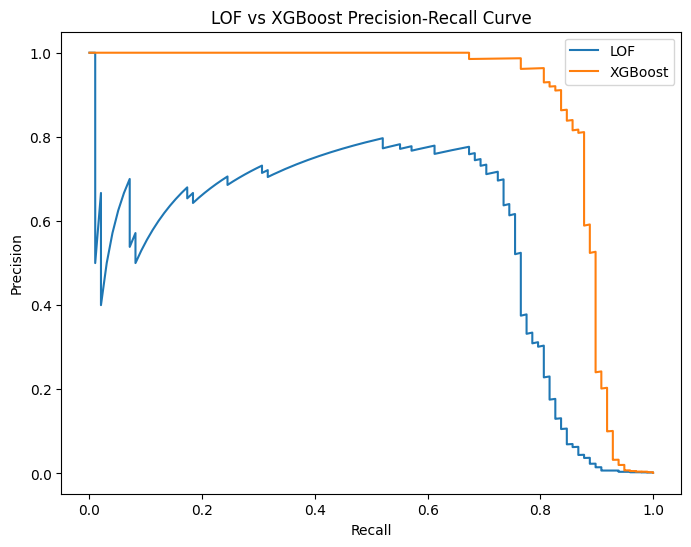

In [53]:
plt.figure(figsize=(8, 6))

plt.plot(
    lof_recall,
    lof_precision,
    label="LOF"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LOF vs XGBoost Precision-Recall Curve")
plt.legend()

plt.show()

In [55]:
top_100_lof = np.argsort(lof_benign_scores)[-100:]

lof_precision_at_100 = Y_test.iloc[top_100_lof].mean()

print(f"LOF Precision@100: {lof_precision_at_100:.4f}")

LOF Precision@100: 0.7100


In [56]:
top_100_xgb = np.argsort(xgb_probs)[-100:]

xgb_precision_at_100 = Y_test.iloc[top_100_xgb].mean()

print(f"XGBoost Precision@100: {xgb_precision_at_100:.4f}")

XGBoost Precision@100: 0.8400


The best unsupervised detector was LOF with a PR-AUC of 0.5692, while XGBoost performed much better with a PR-AUC of about 0.8835. The precision-recall curve also showed that XGBoost maintained higher precision across most recall levels. For precision@100, LOF correctly identified 71 fraud transactions in its top 100 alerts, while XGBoost identified 84. Even though supervised learning performed better overall, the unsupervised detector is still valuable when labeled attack data is limited or when the goal is to detect new attack behavior that was never seen during training. This connects directly to the research dataset because the malicious activity may include behavior that no training set fully represents.

I learned that supervised models can outperform unsupervised detectors when good labeled examples are available, but unsupervised models can still be useful for detecting unknown behavior. I also learned how precision@100 represents what an analyst would actually experience by checking only the highest-ranked alerts. Even though LOF had a lower PR-AUC than XGBoost, finding 71 fraud cases in the top 100 alerts showed that it could still be useful in a real alert queue.

What confused me at first was why we would consider using an unsupervised model when XGBoost clearly performed better. I learned that the advantage of the unsupervised model is not necessarily having the highest score, but being able to detect unusual behavior without needing labeled examples of every attack. This becomes important when future attacks are different from anything that appeared in the training data.

Capstone: For the Week 7 capstone, I compared four different unsupervised anomaly detection methods to my XGBoost model. For the train-on-benign setup, the z-score method had a PR-AUC of 0.1357, Isolation Forest had 0.1741, One-Class SVM had 0.2492, and LOF did the best out of the unsupervised models with a score of 0.5692. XGBoost still did much better with a PR-AUC of about 0.8835, which makes sense because XGBoost actually got to learn from the fraud labels.

When I compared LOF and XGBoost on the precision-recall curve, XGBoost was clearly better overall, but LOF still did pretty well considering it never learned what fraud looked like. For precision@100, LOF found 71 actual fraud cases in its top 100 alerts, while XGBoost found 84. This helped me see the results in a more realistic way because a security analyst would probably be looking at the most suspicious alerts first instead of every single transaction.

Even though XGBoost performed better, I can still see why an unsupervised model would be useful. If there are not enough labeled attacks, or if a new type of attack happens that the model has never seen before, an unsupervised detector can still flag it for being unusual. This connects to the research project because the real dataset has millions of events and some of the malicious behavior might be different from anything the model has already seen. Training on normal behavior gives us another way to catch things that do not fit what the system normally does.